In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# An embedding receives learning through several paths

Chapter 2 · Day 2

Input IDs are categorical addresses. The trainable row they select receives gradients, and a tied output table may receive additional dense classification gradients. A zero prompt loss mask does not remove the prompt from the answer's causal history.

In [2]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/dongxi_llms').exists())
sys.path.insert(0, str(ROOT / 'src'))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(909)
plt.rcParams.update({'figure.figsize': (8, 3.6), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

Prediction: if ID2 appears twice in a batch, are there two independent parameter rows or two contributions to the same row? If prompt loss is zero, must the prompt embedding gradient be zero?

In [3]:
from dongxi_llms.embedding_gradient_lab import repeated_lookup_demo, classifier_path_demo, response_only_loss_demo
lookup = repeated_lookup_demo()
paths = classifier_path_demo()
prompt = response_only_loss_demo()
print('Repeated lookup:', json.dumps(lookup, indent=2))
print('Classifier paths:', json.dumps(paths, indent=2))
print('Prompt gradients:', prompt['prompt_row_gradient_norms'])

Repeated lookup: {
  "input_ids_shape": [
    1,
    3
  ],
  "lookup_output_shape": [
    1,
    3,
    4
  ],
  "nonzero_gradient_rows": [
    2,
    5
  ],
  "row_2_gradient": [
    2.0,
    2.0,
    2.0,
    2.0
  ],
  "row_5_gradient": [
    1.0,
    1.0,
    1.0,
    1.0
  ]
}
Classifier paths: {
  "untied": {
    "tied": false,
    "input_rows": [
      1,
      3
    ],
    "target_row": 4,
    "loss": 0.699771,
    "embedding_gradient_norms": [
      0.0,
      0.3450230062007904,
      0.0,
      0.3450230062007904,
      0.0,
      0.0
    ],
    "nonzero_embedding_gradient_rows": [
      1,
      3
    ]
  },
  "tied": {
    "tied": true,
    "input_rows": [
      1,
      3
    ],
    "target_row": 4,
    "loss": 0.699771,
    "embedding_gradient_norms": [
      0.04501799866557121,
      0.2944929897785187,
      0.05373699963092804,
      0.36406901478767395,
      0.6444140076637268,
      0.003909999970346689
    ],
    "nonzero_embedding_gradient_rows": [
      0,
   

Reference explanation: lookup gradients accumulate into the single shared row indexed by each ID. Tied input/output weights receive the sum of their computational paths. The answer hidden state can read prompt states through causal attention, so answer loss reaches those prompt embedding rows despite zero direct loss at prompt positions.

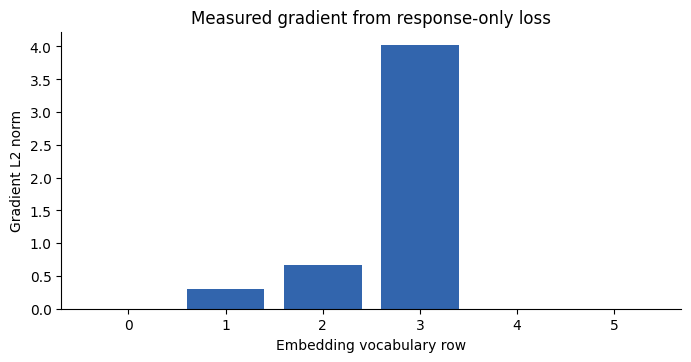

In [4]:
norms = prompt['embedding_gradient_norms']
fig, ax = plt.subplots()
ax.bar(range(len(norms)), norms, color='#3265ad')
ax.set(xlabel='Embedding vocabulary row', ylabel='Gradient L2 norm',
       title='Measured gradient from response-only loss')
plt.show()
assert prompt['prompt_row_gradient_norms']['row_1'] > 0
assert prompt['prompt_row_gradient_norms']['row_2'] > 0

**Saved reference preview — rerun the preceding plot cell for current inputs.**

![03 embedding gradient paths: reference plot 01](../figures/chapter-02/day-02-03_embedding_gradient_paths-01.png)

This fixed image comes from the CPU reference or the explicitly identified saved evidence; changing inputs does not update the preview automatically.

Intervention: detach the prompt representation before attention in a copy of the implementation. Reference: that cuts the relevant gradient path, which differs from assigning prompt labels zero loss weight. A detached source may still contribute values during the forward pass while receiving no parameter update through that path.

Deep checkpoint: is a large gradient row necessarily the most semantically important token? Reference: this norm depends on the example, objective and parameterization. Its meaning is local sensitivity of this loss; semantic importance requires a different claim and intervention.